In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_excel("Telco_customer_churn.xlsx")
df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [5]:
df.shape

(7043, 33)

In [6]:
"""By default, Pandas stores numbers as 64-bit integers (int64), which take up a lot of RAM. 
Because a customer's tenure in this dataset only goes up to 72 months, the data easily fits into 
an 8-bit integer (which can store numbers from -128 to 127). Downcasting to int8 reduces the memory 
footprint of this column by almost 88%, making the pipeline run much faster, especially on large
 datasets." It shows an interviewer that you care about writing efficient, production-grade code,
   not just making models work!"""
df['Tenure Months'] = df['Tenure Months'].astype('int8')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int8   
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [7]:
df['Churn Label'].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

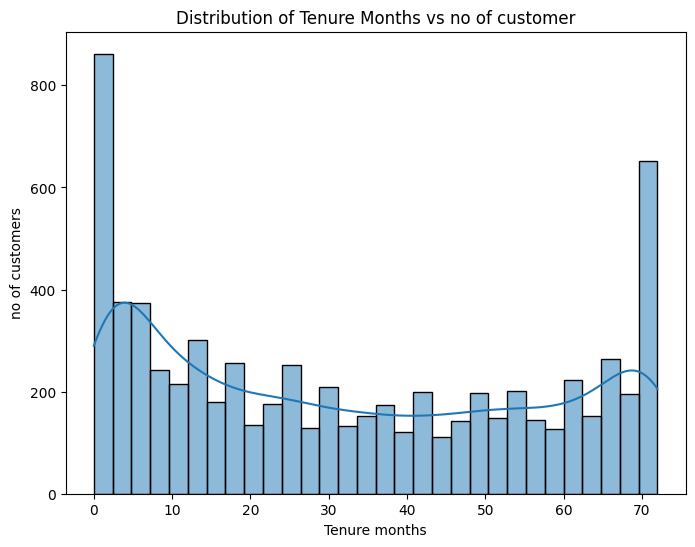

"This graph shows a 'Make or Break' customer lifecycle. Customers either leave almost immediately, or they become completely loyal and stay forever. There is almost no middle ground. This tells the business that our primary problem isn't long-term retention; it's surviving the first 5 months of customer onboarding."

In [8]:
plt.figure(figsize=(8,6))

sns.histplot(
    df['Tenure Months'],
    bins=30,
    kde=True
)
plt.xlabel("Tenure months")
plt.ylabel("no of customers")
plt.title("Distribution of Tenure Months vs no of customer")
plt.show()

#This is a classic bimodal distribution, highlighting two extreme customer segments.
'''This graph shows a 'Make or Break' customer lifecycle. Customers either leave almost immediately, or they become completely loyal and stay forever. There is almost no middle ground. This tells the business that our primary problem isn't long-term retention; it's surviving the first 5 months of customer onboarding.'''


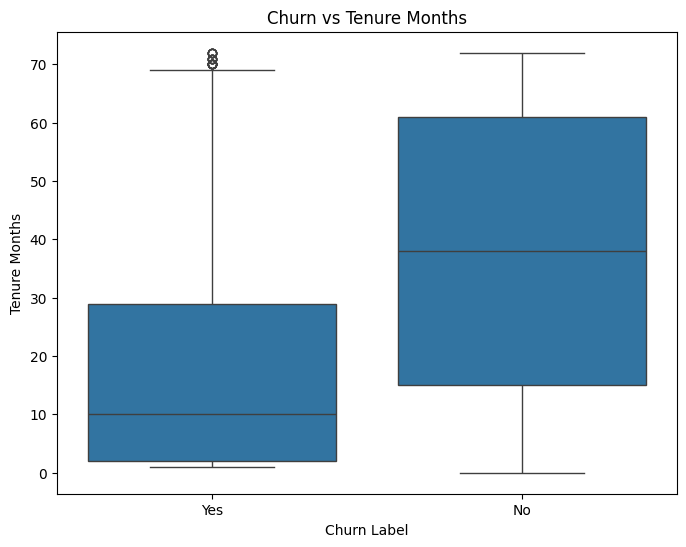

In [9]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x='Churn Label',
    y='Tenure Months',
    data=df
)

plt.xlabel('Churn Label')
plt.ylabel('Tenure Months')
plt.title('Churn vs Tenure Months')

plt.show()
#This graph shows that new customers are flight risks. If a customer is going to cancel, 
# they usually do it within#  the first 10 months. Our long-term customers 
# are highly loyal and rarely leave.

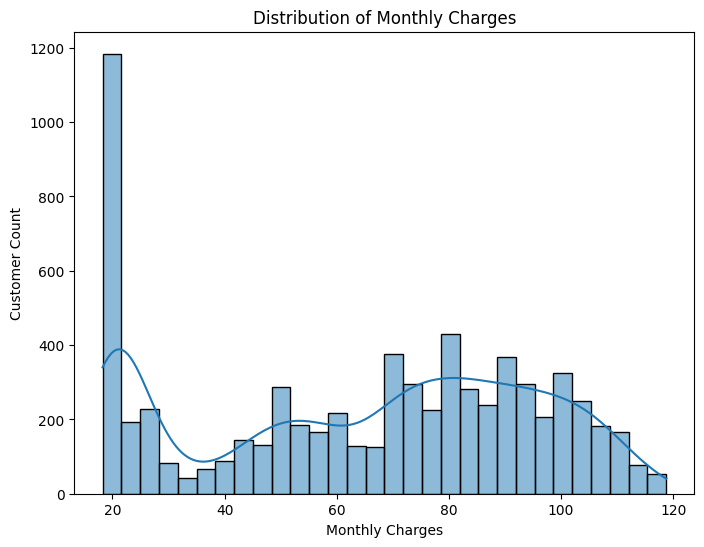

'\nWe analyze MonthlyCharges because it acts as a financial proxy for customer expectations.\n The graph shows a massive group of cheap, stable accounts at $20, and a spread of premium accounts \n over $70. In a churn pipeline, we cross-reference this feature with Churn Label because high monthly \n charges typically correlate heavily with an increased risk of churn, as premium buyers are far quicker \n to jump to a competitor offering a better discount.\n'

In [10]:
plt.figure(figsize=(8,6))
sns.histplot(
    df['Monthly Charges'],
    bins=30,
    kde=True
)

plt.xlabel('Monthly Charges')
plt.ylabel('Customer Count')
plt.title('Distribution of Monthly Charges')

plt.show()

"""
We analyze MonthlyCharges because it acts as a financial proxy for customer expectations.
 The graph shows a massive group of cheap, stable accounts at $20, and a spread of premium accounts 
 over $70. In a churn pipeline, we cross-reference this feature with Churn Label because high monthly 
 charges typically correlate heavily with an increased risk of churn, as premium buyers are far quicker 
 to jump to a competitor offering a better discount.
"""

In [11]:
df['Monthly Charges'].max()

np.float64(118.75)

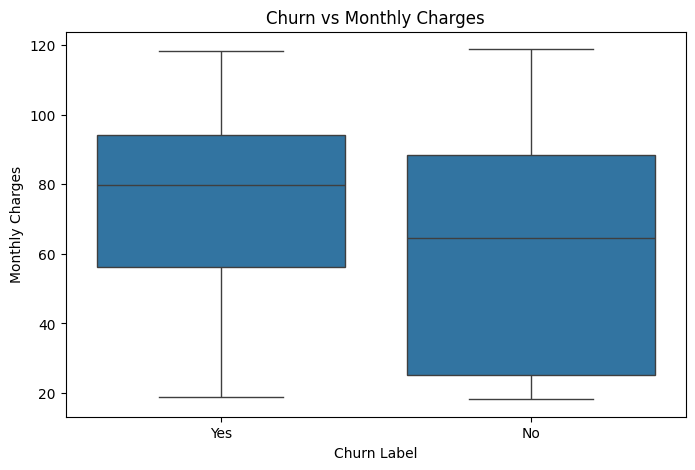

'You are absolutely right. The median monthly charge for churned customers is significantly higher\nat $80 compared to $65 for retained customers. Furthermore, the bottom quartile of the data shows us \nthat customers on cheaper, basic plans rarely churn. This tells the business that premium customers\nare highly price-sensitive and are likely churning to competitors offering cheaper rates for similar\nservices. \nthe "Yes" box doesn\'t stretch down to the $20 or $30 marks, it tells us that out \nof all the people who quit, practically \nnone of them were on a cheap plan.'

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn Label',
    y='Monthly Charges',
    data=df
)

plt.xlabel('Churn Label')
plt.ylabel('Monthly Charges')
plt.title('Churn vs Monthly Charges')

plt.show()

"""You are absolutely right. The median monthly charge for churned customers is significantly higher
at $80 compared to $65 for retained customers. Furthermore, the bottom quartile of the data shows us 
that customers on cheaper, basic plans rarely churn. This tells the business that premium customers
are highly price-sensitive and are likely churning to competitors offering cheaper rates for similar
services. 
the "Yes" box doesn't stretch down to the $20 or $30 marks, it tells us that out 
of all the people who quit, practically 
none of them were on a cheap plan."""

### Boolean Indexing 
-Boolean Indexing is the act of filtering a dataset using True and False values, rather than using row numbers or column names.

-Give me rows 10 through 50," you are saying, "Ask every single row a True/False question, and only give me back the rows that answer True.

-Blazing Speed: Under the hood, Pandas and NumPy process these True/False arrays using optimized C code (vectorization). It is infinitely faster than writing a for loop to check rows one by one.

-Cohort Isolation: This is how you actually do targeted machine learning or business analytics. You rarely analyze a whole dataset at once; you use boolean indexing to isolate specific cohorts (e.g., isolating only the high-risk customers).

-Human Readability: It makes your code read almost like plain English.

In [13]:
#We will use Boolean Indexing to filter our dataset into two distinct groups (Churned vs. Retained) and 
# calculate the 25th, 50th (Median), and 75th percentiles for their Monthly Charges.

'''When you use single brackets ['Monthly Charges'], Pandas pulls that single column out as a 
1-Dimensional list (called a Series). A Series does not display a table header at the top. Instead,
it prints its name at the very bottom of the output (which you can actually see in your screenshot:
Name: Monthly Charges).The Fix: If you want it to print as a clean table with the heading at the top,
you need to tell Pandas to keep it as a 2-Dimensional DataFrame. You do this by using double brackets:'''

df[df['Churn Label']=="Yes"][['Monthly Charges']]

,Monthly Charges
0,53.85
1,70.70
2,99.65
3,104.80
4,103.70
...,...
1864,59.80
1865,44.20
1866,75.75
1867,102.95


### Quantiles
This is just the math/coding version of a percentile. You just divide the percentile by 100.
The 90th percentile is the 0.90 quantile.
The 50th percentile is the 0.50 quantile.

In [14]:
'''Take all the people who quit, line up their monthly bills from cheapest to most expensive, 
and give me the exact dollar amounts at the 25%, 50%, and 75% marks'''

df[df['Churn Label']=="Yes"][["Monthly Charges"]].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,56.15
0.50,79.65
0.75,94.20


In [15]:
df[df['Churn Label']=="No"][["Monthly Charges"]].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,25.100
0.50,64.425
0.75,88.400


### Categorical Analysis : Contract
Categorical analysis means evaluating the distribution of text-based groups in our data. It is vital for placements because it dictates how we encode features—using One-Hot Encoding for non-ordered groups and Ordinal Encoding for ranked groups—ensuring the mathematical algorithms can ingest the data correctly without creating unnecessary data dimension traps.

In [16]:
df['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

In [17]:
df['Contract'].value_counts()
#to see frequency of each category

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [18]:
df['Contract'].count()
#This counts the total number of non-empty rows in that column.

np.int64(7043)

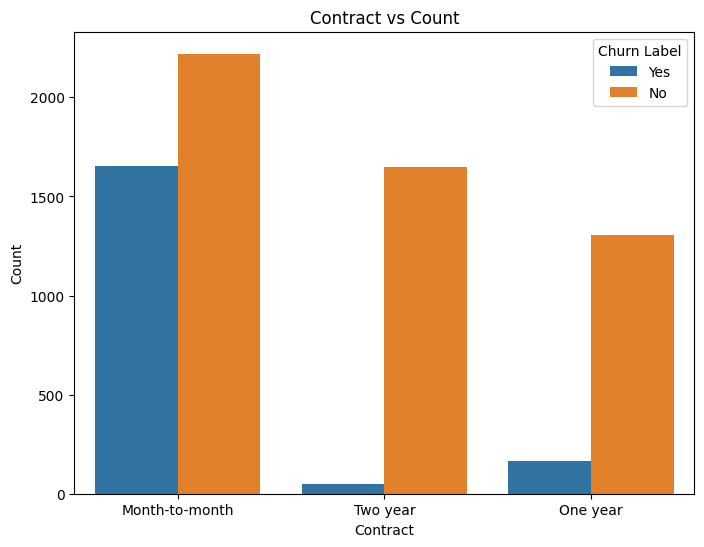

In [19]:
'''This graph explicitly proves that contract length drives customer retention. Customers on 
'Month-to-month' plans are an extremely high flight risk, making up almost our entire churned user base.
In stark contrast, once a customer commits to a 'One year' or 'Two year' contract, their churn rate 
drops to near zero. The immediate business recommendation is to aggressively incentivize month-to-month 
users to sign annual contracts, perhaps by offering a heavy discount on their first year.

This visually proves that once a customer signs a 1 or 2-year contract, the amount of people 
quitting drops to almost zero, while the number of people staying remains very high.

The lack of a lock-in period makes it too easy for month-to-month users to leave. 
The company should aggressively incentivize users to upgrade to annual contracts (e.g.,
 by offering the first month free on a 1-year plan).'''
plt.figure(figsize=(8,6))

sns.countplot(
    x='Contract',
    hue='Churn Label',
    data=df
)

plt.xlabel('Contract')
plt.ylabel('Count')
plt.title('Contract vs Count')

plt.show()

### Categorical analysis : Internet service

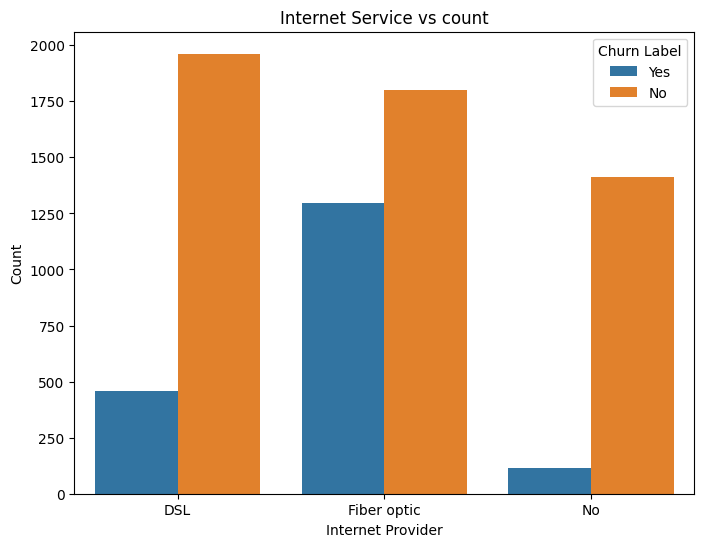

In [20]:
'''The "No Internet" Insight: You correctly identified that these customers are highly stable. 
They just want a basic phone line, so they have no reason to leave.

The "Fiber Optic" Insight: You spotted the massive blue bar. Even though DSL and Fiber Optic have 
a similar number of total users, the churn rate for Fiber Optic is alarming.

my asnwer: This graph tells us the cmount of churning happening based on the Internet provider
poeple who do not have any internet provider have no reason to churn so they stay they are not 
requiring any internet the poeple who are using fiber optics have higher churning rate maybe
because of the speed of internet so we need to check the fiber optic internet privider and 
need to know as to what is the problem

Intresting connection:::
Think back to the previous boxplot about Monthly Charges. We learned that people paying $80+ 
were churning the most. Fiber Optic is almost always the most expensive plan. You just connected 
two different variables to find the root cause: Customers are paying a premium price for Fiber Optic, 
but the quality (speed/reliability) isn't justifying the cost, so they are jumping to competitors.
'''
plt.figure(figsize=(8,6))

sns.countplot(
    x='Internet Service',
    hue='Churn Label',
    data=df
)

plt.xlabel('Internet Provider')
plt.ylabel('Count')
plt.title('Internet Service vs count')
plt.show()

### 10. Categorical Analysis: Payment Method

In [22]:
df['Payment Method'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

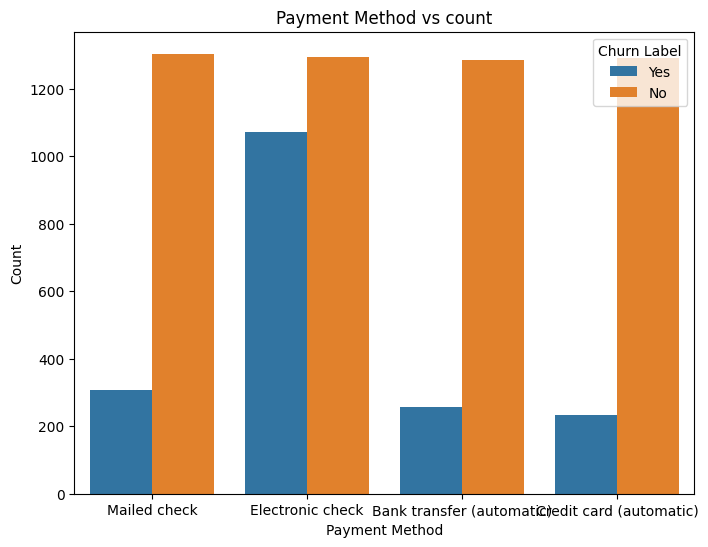

In [ ]:
'''This graph highlights a major behavioral friction point. Customers paying manually via 
Electronic Check have a vastly disproportionate churn rate compared to other methods. In contrast,
automatic payment methods show excellent retention. A high-ROI business recommendation would be to
aggressively push customers toward auto-pay, perhaps by offering a $5 monthly discount for linking
a credit card or bank account, which would stabilize this volatile segment.'''

plt.figure(figsize=(8,6))

sns.countplot(
    x='Payment Method',
    hue='Churn Label',
    data=df
)

plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.title('Payment Method vs count')
plt.show()

Customers using "Electronic check" are churning at an unbelievably high rate compared to everyone else. Why? Because this is a manual, high-friction process. Every single month, these customers have to actively log in, look at their total, and pay their bill. Every month they are reminded of how much they are spending, which creates a recurring psychological trigger to cancel.

"Bank transfer (automatic)" and "Credit card (automatic)". The blue bars are tiny. These are "set it and forget it" payments. The money leaves their account automatically, so they never experience the friction of actively handing over their money. They keep the service simply out of convenience and inertia.


### 11. Categorical Analysis: Tech Support

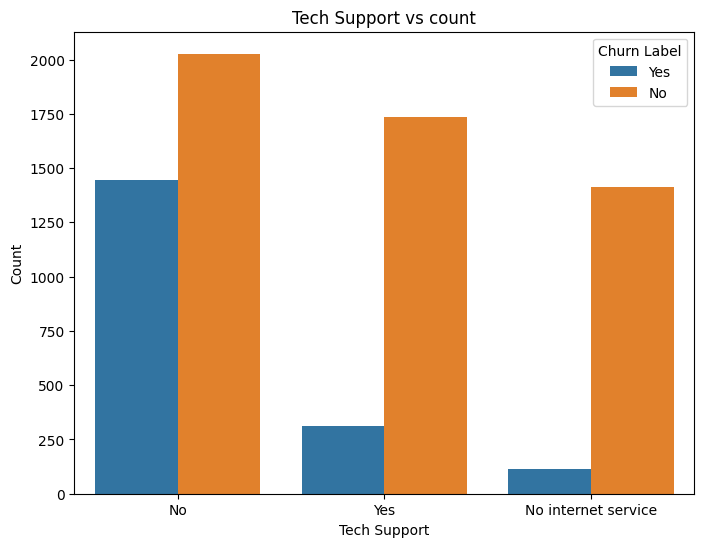

In [25]:
plt.figure(figsize=(8,6))

sns.countplot(
    x='Tech Support',
    hue='Churn Label',
    data=df
)

plt.xlabel('Tech Support')
plt.ylabel('Count')
plt.title('Tech Support vs count')
plt.show()

The Core Red Flag ("No" Tech Support): Customers who do not have tech support show a massive surge in churn. This proves a direct link between unresolved technical frustrations and account cancellation. When users encounter bugs or outages without a lifeline, they leave.

The Retained Safeguard ("Yes" Tech Support): Enrolling in tech support dramatically drops the churn rate. Assisting customers actively creates product stickiness and loyalty.

The Hidden Friction (The "Yes" Churners): As you perfectly noted, a small portion of users with tech support still churn. This indicates that while customer service helps, it cannot entirely fix the underlying infrastructure or pricing issues—like the expensive Fiber Optic bills we uncovered earlier.

The Baseline Group ("No Internet Service"): These accounts require no technical assistance because they only use basic, highly stable phone utilities. Consequently, their churn is negligible.

### SQL aggegrate functions :Viewing avg churn months for two groups 

In [ ]:
avg_tenure=df.groupby("Churn Label")["Tenure Months"].mean()
avg_tenure

#This one line of code calculates the average lifespan of a churning customer versus a loyal customer.
#It will output two simple numbers (e.g., "Yes: 17.9 months, No: 37.5 months")

Churn Label
No     37.569965
Yes    17.979133
Name: Tenure Months, dtype: float64

### Numerical Correlation & Heatmap
To finalize our Exploratory Data Analysis, we will calculate the exact mean tenure of our customer base and generate a Correlation Heatmap to mathematically prove how our numerical features interact with one another.

In [ ]:
'''You run a Correlation Matrix to measure how mathematically connected your numerical columns are to 
each other.Instead of guessing if two things are related, this math gives you a strict score from 
-1.0 to 1.0:

+1.0 (Perfect Positive): When one goes up, the other goes up perfectly.

-1.0 (Perfect Negative): When one goes up, the other goes down perfectly.

0.0 (No Relation): They have absolutely nothing to do with each other.

You do this before training a model to see which features strongly predict your target (Churn Value),
 and to make sure you don't have two features that are essentially identical copies of each other.'''

numerical_cols = ['Tenure Months','Monthly Charges','Churn Value', 'Churn Score', 'CLTV']
correlation_matrix = df[numerical_cols].corr()
correlation_matrix


,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


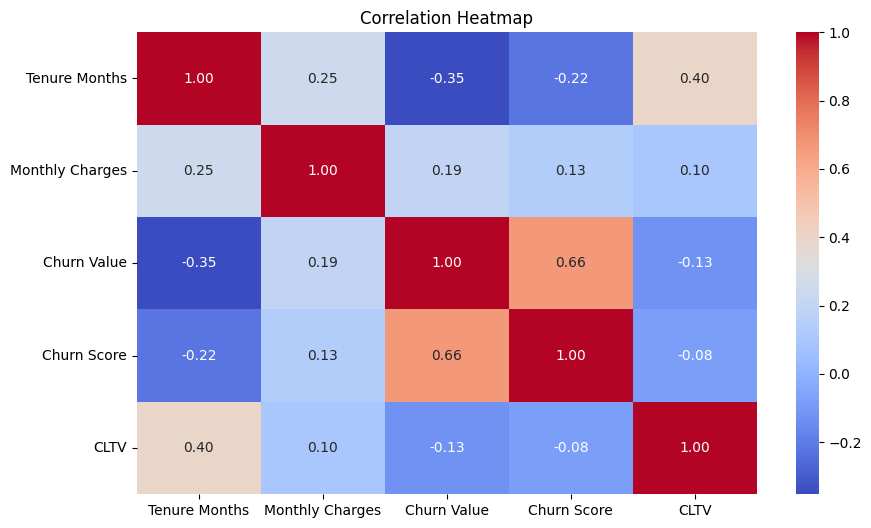

In [29]:
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

### Probability Analysis (Cross-Tabulation)
Our countplot showed a visual spike in churn for month-to-month contracts. To quantify this risk mathematically, we will generate a cross-tabulation table. 

By applying `normalize='index'`, we convert raw customer counts into **churn probabilities** for each contract tier.

In [30]:
pd.crosstab(df['Contract'], df['Churn Label'])

Churn Label,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


pd.crosstab is Pandas' way of creating a pivot table. You handed it two columns (Contract and Churn Label) and it simply counted how many people fall into each bucket.

The Problem: Raw numbers can be deceiving. If you have 10,000 month-to-month customers and only 100 two-year customers, the raw churn numbers will look skewed simply because one group is massively larger than the other.

By adding normalize='index', you told Pandas: "Stop giving me raw customer counts. Instead, force every row to equal 100% (or 1.0), and tell me what percentage of each row quit."

Instead of doing the math in your head, Pandas calculated the exact Churn Probability for you.

In [35]:
pd.crosstab(df['Contract'], df['Churn Label'], normalize='index')

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


**Actionable Business Insight:**
The normalized contingency table provides exact risk metrics:
* **Critical Risk:** Month-to-month customers have an alarming **42.7% probability** of churning.
* **High Loyalty:** Securing a customer on a two-year contract drops their churn probability to a negligible **2.8%**.
* **Recommendation:** The business should prioritize converting month-to-month users into 1-year or 2-year contracts, potentially by absorbing the cost of the first month to lock them into the lower-risk tiers.

### Data Preprocessing: Type Conversion & Handling Hidden Missing Values
During our initial `df.info()` inspection, the `Total Charges` column was classified as an `object` (string) rather than a numerical `float64`. 

This happens because new customers (Tenure = 0) have their total charges recorded as blank spaces, empty string (`" "`) in the raw data. Machine Learning models require strictly numerical inputs, so we must force this column into a numeric type. 

By using `pd.to_numeric` with `errors='coerce'`, we instruct Pandas to convert the strings to floats and gracefully replace any unparseable blank spaces with standard `NaN` values, which we can then filter or impute.

To convert an object to integer::

df['Column Name'] = df['Column Name'].astype(int)
If your column has weird blank spaces or missing data (which is very common in the TotalCharges column of Telecom datasets), .astype(int) will crash. In that case, use this safer method instead:
df['Column Name'] = pd.to_numeric(df['Column Name'], errors='coerce')

You cannot use .astype(int) because Pandas doesn't know what number "Yes" should be. You must use .map() to assign the integers yourself.
-Turns 'Yes' into 1 and 'No' into 0
df['Column Name'] = df['Column Name'].map({'Yes': 1, 'No': 0})

In [32]:
df['Total Charges'] =pd.to_numeric(df['Total Charges'],errors="coerce")
print(df['Total Charges'])

0        108.15
1        151.65
2        820.50
3       3046.05
4       5036.30
         ...   
7038    1419.40
7039    1990.50
7040    7362.90
7041     346.45
7042    6844.50
Name: Total Charges, Length: 7043, dtype: float64


In [33]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges          11
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [34]:
df.isnull().sum().unique()

array([   0,   11, 5174])